# **FGVCAircraft  - CLIP Prompt Tuning**

In [1]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-027mhii0
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-027mhii0
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=3a5f6880b9cfcef4183aa7fdf05d1f03d96fa46bdb034980d7d820153202d2d0
  Stored in directory: /tmp/pip-ephem-wheel-cache-gh9utc45/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
!pip install peft

In [3]:
!pip uninstall -y peft torchao
!pip install peft==0.13.2

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 8.0 MB/s eta 0:00:00


### Imports and  loading FGCVAircraft data

In [4]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F
import clip
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [5]:
class FGVCAircraftDataset(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.root = root
        self.transform = transform

        with open(os.path.join(root, "variants.txt")) as f:
            self.classes = [line.strip() for line in f.readlines()]

        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        split_file = os.path.join(root, f"images_variant_{split}.txt")
        self.samples = []

        with open(split_file) as f:
            for line in f:
                parts = line.strip().split(" ")
                img_name = parts[0]
                label = " ".join(parts[1:])
                img_path = os.path.join(root, "images", f"{img_name}.jpg")

                if label in self.class_to_idx:
                    self.samples.append((img_path, self.class_to_idx[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
#ensures that the images are in the exact format that CLIP was trained on. If this is skipped, then accuracy will drop significantly.
clip_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711),
    ),
])

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/EEEM068 - Applied Machine Learning/COURSEWORK/data" /content/data
#!cp -r "/content/drive/MyDrive/EEEM068 - Applied Machine Learning/COURSEWORK/data" /content/data
root = "/content/data"

In [9]:
train_dataset = FGVCAircraftDataset(root, "train", clip_transform)
val_dataset   = FGVCAircraftDataset(root, "val", clip_transform)
test_dataset  = FGVCAircraftDataset(root, "test", clip_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)

classnames = train_dataset.classes

print("Classes:", len(classnames))

Classes: 100


### Load CLIP and Models

In [10]:
model, _ = clip.load("ViT-B/16", device=device)
model.eval()

100%|███████████████████████████████████████| 335M/335M [00:04<00:00, 80.3MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

##### Zero Shot (Baseline)

In [11]:
def zero_shot_classifier(classnames, template="a photo of a {}"):
    texts = [template.format(c) for c in classnames]
    tokens = clip.tokenize(texts).to(device)

    with torch.no_grad():
        text_features = model.encode_text(tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    return text_features

##### Prompt Ensemble

In [12]:
templates = [
    "a photo of the {}",
    "a photo of a {}",
    "a blurry photo of a {}",
    "a close-up of a {}",
    "a rendering of a {}"
]

def prompt_ensemble(classnames):
    feats = []
    for t in templates:
        feats.append(zero_shot_classifier(classnames, t))
    return torch.stack(feats).mean(dim=0)

##### CuPL

In [13]:
cupl_templates = [
    "a detailed photo of a {}, a type of aircraft",
    "a high resolution image of a {} airplane",
    "an aircraft model known as {}",
    "a side view of a {} aircraft"
]

def cupl_classifier(classnames):
    feats = []
    for t in cupl_templates:
        feats.append(zero_shot_classifier(classnames, t))
    return torch.stack(feats).mean(dim=0)

##### CoOp

In [50]:
class CoOp(torch.nn.Module):
    def __init__(self, classnames, clip_model, n_ctx=16):
        super().__init__()

        self.classnames = classnames
        self.clip_model = clip_model
        self.n_cls = len(classnames)
        self.ctx_dim = 512

        # Per-class learnable offset; zero init = starts exactly at zero-shot
        self.ctx = torch.nn.Parameter(torch.zeros(self.n_cls, self.ctx_dim))

        with torch.no_grad():
            texts = [f"a photo of a {c}" for c in classnames]
            tokens = clip.tokenize(texts).to(device)
            text_features = clip_model.encode_text(tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        self.register_buffer("base_text_features", text_features)

    def forward(self):
        # Each class gets its own independent shift — prevents collapse under normalisation
        text_features = self.base_text_features + self.ctx
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        return text_features

In [51]:
def compute_validation_loss(model, clip_model, val_loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0

    with torch.no_grad():
        text_features = model()

        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            image_features = clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            text_features = text_features.to(image_features.dtype)

            logits = image_features @ text_features.T
            loss = criterion(logits, labels)
            total_loss += loss.item()

    return total_loss / len(val_loader)

In [52]:
clip_model = model

def train_coop(prompt_model, clip_model, train_loader, val_loader, epochs=10, lr=1e-3):
    prompt_model.train()
    optimizer = torch.optim.Adam(prompt_model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    clip_model.eval()

    for epoch in range(epochs):
        prompt_model.train()
        total_loss = 0.0
        pbar = tqdm(train_loader, desc=f"CoOp Epoch {epoch+1}/{epochs}")

        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                image_features = clip_model.encode_image(images)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            text_features = prompt_model()
            text_features = text_features.to(image_features.dtype)

            logits = image_features @ text_features.T
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_loss = compute_validation_loss(prompt_model, clip_model, val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_loss:.4f} | Val: {val_loss:.4f}")

    return prompt_model, train_losses, val_losses

##### CoCoOp

In [65]:
class CoCoOp(torch.nn.Module):
    def __init__(self, classnames, clip_model, n_ctx=16):
        super().__init__()

        self.classnames = classnames
        self.clip_model = clip_model
        self.n_cls = len(classnames)
        self.ctx_dim = 512

        # No shared ctx — meta_net alone provides per-image conditioning.
        # A shared ctx shift would collapse all class features the same way as CoOp.
        self.meta_net = torch.nn.Sequential(
            torch.nn.Linear(self.ctx_dim, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, self.ctx_dim)
        )

        # Zero init the output layer so meta_net starts as a zero shift (= zero-shot at epoch 0)
        torch.nn.init.zeros_(self.meta_net[2].weight)
        torch.nn.init.zeros_(self.meta_net[2].bias)

        with torch.no_grad():
            texts = [f"a photo of a {c}" for c in classnames]
            tokens = clip.tokenize(texts).to(device)
            text_features = clip_model.encode_text(tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            self.register_buffer("base_text_features", text_features)

    def forward(self, image_features):
        image_features = image_features.float()

        shift = self.meta_net(image_features)  # (B, 512)

        # shift is per-image but shared across classes — each class moves by the same
        # image-dependent offset, so relative class separability is preserved
        text_features = self.base_text_features.unsqueeze(0) + shift.unsqueeze(1)  # (B, n_cls, 512)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        return text_features

In [66]:
def compute_validation_loss_cocoop(model, clip_model, val_loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            image_features = clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            prompt_features = model(image_features)
            prompt_features = prompt_features.to(image_features.dtype)

            logits = torch.einsum("bd,bcd->bc", image_features, prompt_features)
            loss = criterion(logits, labels)
            total_loss += loss.item()

    return total_loss / len(val_loader)

In [67]:
def train_cocoop(model, train_loader, val_loader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"CoCoOp Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)

            with torch.no_grad():
                image_features = model.clip_model.encode_image(images)
                image_features /= image_features.norm(dim=-1, keepdim=True)

            prompt_features = model(image_features)
            prompt_features = prompt_features.to(image_features.dtype)

            logits = torch.einsum("bd,bcd->bc", image_features, prompt_features)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_loss = compute_validation_loss_cocoop(model, clip_model, val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_loss:.4f} | Val: {val_loss:.4f}")

    return model, train_losses, val_losses

In [68]:
def cocoop_get_text_features(model, dataloader):
    model.eval()
    all_shifts = []

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            image_features = model.clip_model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            shift = model.meta_net(image_features.float())
            all_shifts.append(shift)

    mean_shift = torch.cat(all_shifts).mean(dim=0)  # (512,)

    text_features = model.base_text_features + mean_shift.unsqueeze(0)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    return text_features

##### PromptSRC

In [83]:
class PromptSRC(torch.nn.Module):
    def __init__(self, classnames, clip_model, n_ctx=16, alpha=0.1):
        super().__init__()

        self.classnames = classnames
        self.clip_model = clip_model
        self.n_cls = len(classnames)
        self.ctx_dim = 512
        self.alpha = alpha

        # Per-class offset, zero init = starts at zero-shot
        self.ctx = torch.nn.Parameter(torch.zeros(self.n_cls, self.ctx_dim))

        with torch.no_grad():
            texts = [f"a photo of a {c}" for c in classnames]
            tokens = clip.tokenize(texts).to(device)
            text_features = clip_model.encode_text(tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        self.register_buffer("base_text_features", text_features)

    def forward(self):
        # Per-class shift — each class moves independently
        learned = self.base_text_features + self.ctx
        learned = learned / learned.norm(dim=-1, keepdim=True)
        return learned

    def regularisation_loss(self, text_features):
        # Cosine distance: keep learned features directionally close to CLIP hand-crafted ones
        cos_sim = torch.sum(text_features * self.base_text_features, dim=-1)
        return torch.mean(1.0 - cos_sim)

In [84]:
def train_promptsrc(model, clip_model, train_loader, val_loader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    clip_model.eval()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        pbar = tqdm(train_loader, desc=f"PromptSRC Epoch {epoch+1}/{epochs}")

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            with torch.no_grad():
                image_features = clip_model.encode_image(images)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            text_features = model()
            text_features = text_features.to(image_features.dtype)

            logits = image_features @ text_features.T
            ce_loss = criterion(logits, labels)
            reg_loss = model.regularisation_loss(text_features)
            loss = ce_loss + model.alpha * reg_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_loss = compute_validation_loss(model, clip_model, val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_loss:.4f} | Val: {val_loss:.4f}")

    return model, train_losses, val_losses

##### KgCoOp

In [61]:
class KgCoOp(torch.nn.Module):
    def __init__(self, classnames, clip_model, n_ctx=16, lambda_kg=0.1):
        super().__init__()

        self.classnames = classnames
        self.clip_model = clip_model
        self.n_cls = len(classnames)
        self.ctx_dim = 512
        self.lambda_kg = lambda_kg

        # Per-class offset, zero init = starts at zero-shot
        self.ctx = torch.nn.Parameter(torch.zeros(self.n_cls, self.ctx_dim))

        with torch.no_grad():
            texts = [f"a photo of a {c}" for c in classnames]
            tokens = clip.tokenize(texts).to(device)
            text_features = clip_model.encode_text(tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        self.register_buffer("base_text_features", text_features)

    def forward(self):
        # Per-class shift — each class moves independently, no collapse under normalisation
        text_features = self.base_text_features + self.ctx
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        return text_features

    def kg_loss(self, text_features):
        # Cosine distance: penalises directional drift from hand-crafted CLIP features
        cos_sim = torch.sum(text_features * self.base_text_features, dim=-1)
        return torch.mean(1.0 - cos_sim)

In [62]:
def train_kgcoop(model, clip_model, train_loader, val_loader, epochs=10, lr=1e-3, lambda_reg=0.1):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    clip_model.eval()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        pbar = tqdm(train_loader, desc=f"KgCoOp Epoch {epoch+1}/{epochs}")

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            with torch.no_grad():
                image_features = model.clip_model.encode_image(images)
                image_features /= image_features.norm(dim=-1, keepdim=True)

            prompt_features = model()
            prompt_features = prompt_features.to(image_features.dtype)
            logits = image_features @ prompt_features.T

            ce_loss = criterion(logits, labels)
            kg_loss = model.kg_loss(prompt_features)
            loss = ce_loss + lambda_reg * kg_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_loss = compute_validation_loss(model, clip_model, val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_loss:.4f} | Val: {val_loss:.4f}")

    return model, train_losses, val_losses

##### Prograd

In [75]:
class ProGrad(CoOp):
    pass

def train_prograd(model, clip_model, train_loader, val_loader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    clip_model.eval()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        pbar = tqdm(train_loader, desc=f"ProGrad Epoch {epoch+1}/{epochs}")

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            with torch.no_grad():
                image_features = clip_model.encode_image(images)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            text_features = model()
            text_features = text_features.to(image_features.dtype)
            logits = image_features @ text_features.T
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_loss = compute_validation_loss(model, clip_model, val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_loss:.4f} | Val: {val_loss:.4f}")

    return model, train_losses, val_losses

##### MaPLe

In [79]:
class maple(torch.nn.Module):
    def __init__(self, classnames, clip_model, n_ctx=16):
        super().__init__()

        self.classnames = classnames
        self.clip_model = clip_model
        self.n_cls = len(classnames)
        self.ctx_dim = 512

        # Per-class text offset, zero init = starts at zero-shot
        self.ctx = torch.nn.Parameter(torch.zeros(self.n_cls, self.ctx_dim))

        # Shared image-side shift — moves all image features together, no collapse risk
        self.img_shift = torch.nn.Parameter(torch.zeros(self.ctx_dim))

        with torch.no_grad():
            texts = [f"a photo of a {c}" for c in classnames]
            tokens = clip.tokenize(texts).to(device)
            text_features = clip_model.encode_text(tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        self.register_buffer("base_text_features", text_features)

    def forward(self):
        # Per-class shift — each class moves independently
        text_features = self.base_text_features + self.ctx
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        return text_features

    def adapt_image(self, image_features):
        image_features = image_features.float() + self.img_shift
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        return image_features

In [80]:
def compute_validation_loss_maple(model, clip_model, val_loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0

    with torch.no_grad():
        text_features = model()

        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            image_features = clip_model.encode_image(images)
            image_features = model.adapt_image(image_features)
            text_features = text_features.to(image_features.dtype)

            logits = image_features @ text_features.T
            loss = criterion(logits, labels)
            total_loss += loss.item()

    return total_loss / len(val_loader)

In [81]:
def train_maple(model, clip_model, train_loader, val_loader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    clip_model.eval()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        pbar = tqdm(train_loader, desc=f"MaPLe Epoch {epoch+1}/{epochs}")

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            with torch.no_grad():
                image_features = clip_model.encode_image(images)

            image_features = model.adapt_image(image_features)
            text_features = model()
            text_features = text_features.to(image_features.dtype)

            logits = image_features @ text_features.T
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_loss = compute_validation_loss_maple(model, clip_model, val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_loss:.4f} | Val: {val_loss:.4f}")

    return model, train_losses, val_losses

##### LoRA

In [30]:
class LoRACLIP(nn.Module):

    def __init__(self, clip_model, num_classes):

        super().__init__()

        self.clip_model = clip_model

        # Freeze everything first
        for param in self.clip_model.parameters():
            param.requires_grad = False

        # CORRECT target modules for OpenAI CLIP
        lora_config = LoraConfig(
            r=32,
            lora_alpha=64,
            target_modules=["c_fc", "c_proj"],
            lora_dropout=0.05,
            bias="none"
        )

        # Apply LoRA to visual transformer
        self.clip_model.visual.transformer = get_peft_model(
            self.clip_model.visual.transformer,
            lora_config
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(512),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, images):

        image_features = self.clip_model.encode_image(images)

        # avoid fp16 instability
        image_features = image_features.float()

        image_features = image_features / (
            image_features.norm(dim=-1, keepdim=True) + 1e-6
        )

        logits = self.classifier(image_features)

        return logits

In [31]:
def compute_validation_loss_lora(model, val_loader):

    model.eval()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if torch.isnan(loss):
                continue

            total_loss += loss.item()

    return total_loss / len(val_loader)

In [32]:
def train_lora(model,train_loader,val_loader,epochs=10,lr=5e-4):

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    scaler = torch.cuda.amp.GradScaler()

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    best_acc = 0

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            try:

                with torch.cuda.amp.autocast():

                    logits = model(images)

                    loss = criterion(logits, labels)

                # NaN/Inf protection
                if not torch.isfinite(loss):
                    continue

                scaler.scale(loss).backward()

                scaler.unscale_(optimizer)

                # Prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                scaler.step(optimizer)
                scaler.update()

            except RuntimeError as e:

                print("Runtime Error:", e)
                torch.cuda.empty_cache()
                continue

            running_loss += loss.item()

            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

        scheduler.step()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        val_loss = compute_validation_loss_lora(
            model,
            val_loader
        )

        # Validation Accuracy
        model.eval()

        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)

                preds = logits.argmax(dim=1)

                val_correct += (preds == labels).sum().item()

                val_total += labels.size(0)

        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Train Acc: {train_acc:.4f}")
        print(f"Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                "best_lora_model.pt"
            )

            print("Best LoRA model saved.")

    return (model,train_losses,val_losses,train_accs,val_accs)

##### Fusion - Static

In [33]:
class Fusion(torch.nn.Module):
    def __init__(self, models):
        super().__init__()
        self.models = models

    def forward(self):
        #return self.models[0]()
        return [m() for m in self.models]

In [34]:
def train_fusion_static(fusion_model, clip_model, train_loader, val_loader, epochs = 10):
    fusion_model.eval()
    clip_model.eval()
    criterion = torch.nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    with torch.no_grad():
      text_features_list = fusion_model()
      text_features_list = [tf.float() for tf in text_features_list]

    for epoch in range(epochs):
      # TRAIN LOSS
      total_loss = 0.0
      desc=f"Fusion Static Train Epoch {epoch+1}/{epochs}"

      for images, labels in tqdm(train_loader, desc="Fusion Static Train"): #train_loader:
          images, labels = images.to(device), labels.to(device)

          with torch.no_grad():
              image_features = clip_model.encode_image(images)
              image_features = image_features / image_features.norm(dim=-1, keepdim=True)
              image_features = image_features.float()

          logits_list = []
          for tf in text_features_list:
              tf = tf.to(image_features.device)
              #tf = tf.to(image_features.dtype)
              logits = image_features @ tf.T

              logits = logits.float()
              logits_list.append(logits)

          fused_logits = sum(logits_list) / len(logits_list)

          loss = criterion(fused_logits, labels)
          total_loss += loss.item()

      train_losses.append(total_loss / len(train_loader))

      #VALIDATION LOSS
      total_loss = 0.0

      for images, labels in tqdm(val_loader, desc="Fusion Static Val"): #val_loader:
          images, labels = images.to(device), labels.to(device)

          with torch.no_grad():
              image_features = clip_model.encode_image(images)
              image_features = image_features / image_features.norm(dim=-1, keepdim=True)
              image_features = image_features.float()

          logits_list = []
          for tf in text_features_list:
              #tf = tf.to(image_features.dtype)
              tf = tf.to(image_features.device)
              logits = image_features @ tf.T
              logits = logits.float()
              logits_list.append(logits)

          fused_logits = sum(logits_list) / len(logits_list)

          loss = criterion(fused_logits, labels)
          total_loss += loss.item()

    val_losses.append(total_loss / len(val_loader))

    return fusion_model, train_losses, val_losses

##### Fusion - Dynamic

In [95]:
class FusionDynamicModel(torch.nn.Module):
    def __init__(self, maple_model, cocoop_model):
        super().__init__()
        self.maple = maple_model
        self.cocoop = cocoop_model
        self.clip_model = maple_model.clip_model

In [96]:

def train_fusion_dynamic(model, train_loader, val_loader):
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    train_losses, val_losses = [], []

    # -------- TRAIN --------
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            image_features = model.clip_model.encode_image(images)
        maple_img = model.maple.adapt_image(image_features)
        maple_text = model.maple()
        maple_text = maple_text.to(maple_img.dtype)
        logits_maple = maple_img @ maple_text.T

        cocoop_img = image_features / image_features.norm(dim=-1, keepdim=True)
        cocoop_text = model.cocoop(cocoop_img)
        cocoop_text = cocoop_text.to(cocoop_img.dtype)
        logits_cocoop = torch.einsum("bd,bcd->bc", cocoop_img, cocoop_text)

        fused_logits = (logits_maple + logits_cocoop) / 2
        loss = criterion(fused_logits, labels)
        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))

    # -------- VAL --------
    total_loss = 0.0
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            image_features = model.clip_model.encode_image(images)
        maple_img = model.maple.adapt_image(image_features)
        maple_text = model.maple()
        maple_text = maple_text.to(maple_img.dtype)
        logits_maple = maple_img @ maple_text.T

        cocoop_img = image_features / image_features.norm(dim=-1, keepdim=True)
        cocoop_text = model.cocoop(cocoop_img)
        cocoop_text = cocoop_text.to(cocoop_img.dtype)
        logits_cocoop = torch.einsum("bd,bcd->bc", cocoop_img, cocoop_text)

        fused_logits = (logits_maple + logits_cocoop) / 2
        loss = criterion(fused_logits, labels)
        total_loss += loss.item()

    val_losses.append(total_loss / len(val_loader))
    return model, train_losses, val_losses

In [97]:
def evaluate_fusion_dynamic(maple_model, cocoop_model, dataloader, name="Fusion Dynamic"):
    maple_model.eval()
    cocoop_model.eval()

    correct1, correct5, total = 0, 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"{name} Progress"):
            images, labels = images.to(device), labels.to(device)
            image_features = maple_model.clip_model.encode_image(images)

            maple_img = maple_model.adapt_image(image_features)
            maple_text = maple_model()
            maple_text = maple_text.to(maple_img.dtype)
            logits_maple = maple_img @ maple_text.T

            cocoop_img = image_features / image_features.norm(dim=-1, keepdim=True)
            cocoop_text = cocoop_model(cocoop_img)
            cocoop_text = cocoop_text.to(cocoop_img.dtype)
            logits_cocoop = torch.einsum("bd,bcd->bc", cocoop_img, cocoop_text)

            fused_logits = (logits_maple + logits_cocoop) / 2

            # Top-1
            preds = fused_logits.argmax(dim=1)
            correct1 += (preds == labels).sum().item()

            # Top-5
            top5 = fused_logits.topk(5, dim=1).indices
            correct5 += sum([labels[i] in top5[i] for i in range(len(labels))])

            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    top1 = correct1 / total
    top5 = correct5 / total
    print(f"{name} Top-1: {top1:.4f}, Top-5: {top5:.4f}")
    return top1, top5, y_true, y_pred

### Evaluate

##### Evaluation Function

In [38]:
def evaluate(text_features, dataloader, name="Model"):
    correct1, correct5, total = 0, 0, 0
    y_true, y_pred = [], []

    print(f"\nEvaluating {name}...")
    start_time = time.time()

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"{name} Progress"):
            images = images.to(device)
            labels = labels.to(device)

            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            text_features = text_features.to(image_features.dtype)
            #logits = image_features @ text_features.T

            logits = image_features @ text_features.T
### use both top1 and top5 accuracies because the airplane classes are very similar
            # Top-1
            preds = logits.argmax(dim=1)
            correct1 += (preds == labels).sum().item()

            # Top-5
            # is the correct answer in the first 5 guesses
            top5 = logits.topk(5, dim=1).indices
            correct5 += sum([labels[i] in top5[i] for i in range(len(labels))])

            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    end_time = time.time()
    print(f"{name} completed in {end_time - start_time:.2f} seconds")

    return correct1/total, correct5/total, y_true, y_pred

In [39]:
def evaluate_prompt_variance(classnames, templates, dataloader, name="Model"):
    top1_scores = []
    top5_scores = []

    print(f"\nEvaluating variance for {name}...")

    for i, t in enumerate(templates):
        print(f"\nTemplate {i+1}/{len(templates)}: {t}")

        # Build text features for this prompt
        text_features = zero_shot_classifier(classnames, t)

        #evaluation function
        top1, top5, _, _ = evaluate(
            text_features,
            dataloader,
            name=f"{name} | Prompt {i+1}"
        )

        top1_scores.append(top1)
        top5_scores.append(top5)

    # Compute statistics
    mean_top1 = np.mean(top1_scores)
    var_top1  = np.var(top1_scores)

    mean_top5 = np.mean(top5_scores)
    var_top5  = np.var(top5_scores)

    print("\n===== VARIANCE RESULTS =====")
    print(f"{name} Mean Top-1: {mean_top1:.4f}")
    print(f"{name} Var  Top-1: {var_top1:.6f}")
    print(f"{name} Mean Top-5: {mean_top5:.4f}")
    print(f"{name} Var  Top-5: {var_top5:.6f}")

    return {
        "top1_scores": top1_scores,
        "top5_scores": top5_scores,
        "mean_top1": mean_top1,
        "var_top1": var_top1,
        "mean_top5": mean_top5,
        "var_top5": var_top5
    }

In [40]:
def evaluate_fusion_static_model(fusion_model, clip_model, dataloader, name="Fusion"):
    fusion_model.eval()

    correct1, correct5, total = 0, 0, 0

    with torch.no_grad():
        text_features_list = fusion_model()

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            image_features = clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            logits_list = []
            for tf in text_features_list:
                tf = tf.to(image_features.dtype)
                logits = image_features @ tf.T
                logits_list.append(logits)

            fused_logits = sum(logits_list) / len(logits_list)

            preds = fused_logits.argmax(dim=1)
            correct1 += (preds == labels).sum().item()

            top5 = fused_logits.topk(5, dim=1).indices
            correct5 += sum([labels[i] in top5[i] for i in range(labels.size(0))])

            total += labels.size(0)

    top1 = correct1 / total
    top5 = correct5 / total

    print(f"{name} Top-1: {top1:.4f}, Top-5: {top5:.4f}")
    return top1, top5

In [41]:
def evaluate_lora(model, dataloader, name="LoRA"):

    correct1, correct5, total = 0, 0, 0
    y_true, y_pred = [], []

    print(f"\nEvaluating {name}...")
    start_time = time.time()

    model.eval()

    with torch.no_grad():

        for images, labels in tqdm(
            dataloader,
            desc=f"{name} Progress"
        ):

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            # Top-1
            preds = logits.argmax(dim=1)

            correct1 += (preds == labels).sum().item()

            # Top-5
            top5 = logits.topk(5, dim=1).indices

            correct5 += sum(
                [labels[i] in top5[i] for i in range(len(labels))]
            )

            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    end_time = time.time()

    print(
        f"{name} completed in "
        f"{end_time - start_time:.2f} seconds"
    )

    return (correct1 / total, correct5 / total, y_true, y_pred)

##### Evaluation Metrics

In [42]:
results = {}

In [43]:
# Zero-shot
zs_features = zero_shot_classifier(classnames)
results["Zero-shot"] = evaluate(zs_features, test_loader)


Evaluating Model...


Model Progress: 100%|██████████| 53/53 [01:04<00:00,  1.22s/it]

Model completed in 64.77 seconds


In [44]:
# Ensemble
ens_features = prompt_ensemble(classnames)
results["Ensemble"] = evaluate(ens_features, test_loader)


Evaluating Model...


Model Progress: 100%|██████████| 53/53 [01:01<00:00,  1.15s/it]

Model completed in 61.03 seconds


In [45]:
ensemble_prompt_results = evaluate_prompt_variance(classnames, templates, test_loader, name="Prompt Ensemble")


Evaluating variance for Prompt Ensemble...

Template 1/5: a photo of the {}

Evaluating Prompt Ensemble | Prompt 1...


Prompt Ensemble | Prompt 1 Progress: 100%|██████████| 53/53 [01:00<00:00,  1.14s/it]


Prompt Ensemble | Prompt 1 completed in 60.34 seconds

Template 2/5: a photo of a {}

Evaluating Prompt Ensemble | Prompt 2...


Prompt Ensemble | Prompt 2 Progress: 100%|██████████| 53/53 [01:01<00:00,  1.16s/it]


Prompt Ensemble | Prompt 2 completed in 61.33 seconds

Template 3/5: a blurry photo of a {}

Evaluating Prompt Ensemble | Prompt 3...


...

Prompt Ensemble | Prompt 3 completed in 61.59 seconds

Template 4/5: a close-up of a {}

Evaluating Prompt Ensemble | Prompt 4...


Prompt Ensemble | Prompt 4 Progress: 100%|██████████| 53/53 [01:00<00:00,  1.15s/it]


Prompt Ensemble | Prompt 4 completed in 60.94 seconds

Template 5/5: a rendering of a {}

Evaluating Prompt Ensemble | Prompt 5...


Prompt Ensemble | Prompt 5 Progress: 100%|██████████| 53/53 [01:01<00:00,  1.16s/it]

Prompt Ensemble | Prompt 5 completed in 61.50 seconds

===== VARIANCE RESULTS =====
Prompt Ensemble Mean Top-1: 0.2258
Prompt Ensemble Var  Top-1: 0.000063
Prompt Ensemble Mean Top-5: 0.5761
Prompt Ensemble Var  Top-5: 0.000066


In [46]:
# CuPL
cupl_features = cupl_classifier(classnames)
results["CuPL"] = evaluate(cupl_features, test_loader)


Evaluating Model...


Model Progress: 100%|██████████| 53/53 [01:00<00:00,  1.14s/it]

Model completed in 60.29 seconds


In [47]:
cupl_prompt_results = evaluate_prompt_variance(classnames,cupl_templates,test_loader,name="CuPL")


Evaluating variance for CuPL...

Template 1/4: a detailed photo of a {}, a type of aircraft

Evaluating CuPL | Prompt 1...


CuPL | Prompt 1 Progress: 100%|██████████| 53/53 [01:03<00:00,  1.20s/it]


CuPL | Prompt 1 completed in 63.66 seconds

Template 2/4: a high resolution image of a {} airplane

Evaluating CuPL | Prompt 2...


CuPL | Prompt 2 Progress: 100%|██████████| 53/53 [01:01<00:00,  1.16s/it]


CuPL | Prompt 2 completed in 61.29 seconds

Template 3/4: an aircraft model known as {}

Evaluating CuPL | Prompt 3...


CuPL | Prompt 3 Progress: 100%|██████████| 53/53 [01:01<00:00,  1.16s/it]


CuPL | Prompt 3 completed in 61.73 seconds

Template 4/4: a side view of a {} aircraft

Evaluating CuPL | Prompt 4...


CuPL | Prompt 4 Progress: 100%|██████████| 53/53 [01:02<00:00,  1.17s/it]

CuPL | Prompt 4 completed in 62.11 seconds

===== VARIANCE RESULTS =====
CuPL Mean Top-1: 0.2376
CuPL Var  Top-1: 0.000095
CuPL Mean Top-5: 0.5974
CuPL Var  Top-5: 0.000077


In [55]:
all_losses = {} ### plotting training ad validation losses

In [53]:
# CoOp
coop_model, coop_train_losses, coop_val_losses = train_coop(CoOp(classnames, clip_model).to(device), clip_model, train_loader, val_loader)
coop_text_features = coop_model()
results["CoOp"] = evaluate(coop_text_features, test_loader, name="CoOp")

CoOp Epoch 1/10: 100%|██████████| 53/53 [01:07<00:00,  1.27s/it, loss=4.46]


Epoch 1/10 | Train: 4.5032 | Val: 4.4588


CoOp Epoch 2/10: 100%|██████████| 53/53 [01:07<00:00,  1.27s/it, loss=4.41]


Epoch 2/10 | Train: 4.4275 | Val: 4.4116


CoOp Epoch 3/10: 100%|██████████| 53/53 [01:02<00:00,  1.19s/it, loss=4.38]


...

Epoch 9/10 | Train: 4.3236 | Val: 4.3413


CoOp Epoch 10/10: 100%|██████████| 53/53 [01:02<00:00,  1.18s/it, loss=4.28]


Epoch 10/10 | Train: 4.3208 | Val: 4.3387

Evaluating CoOp...


CoOp Progress: 100%|██████████| 53/53 [01:02<00:00,  1.17s/it]

CoOp completed in 62.01 seconds


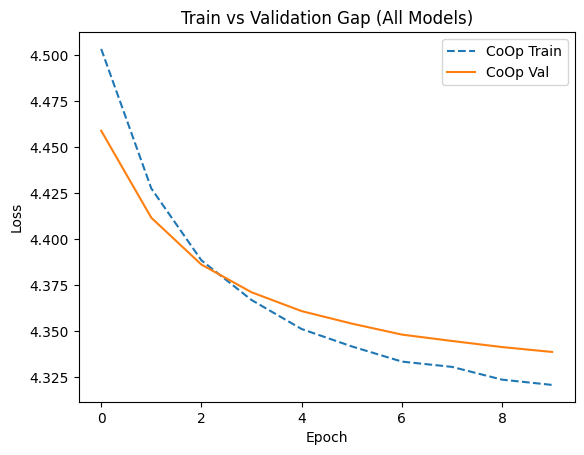

In [56]:
all_losses["CoOp"] = {"train": coop_train_losses, "val": coop_val_losses}
plt.figure()

for name, losses in all_losses.items():
    plt.plot(losses["train"], linestyle='--', label=f"{name} Train")
    plt.plot(losses["val"], linestyle='-', label=f"{name} Val")

plt.title("Train vs Validation Gap (All Models)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [69]:
#CoCoOp
cocoop_model, cocoop_train_losses, cocoop_val_losses = train_cocoop(CoCoOp(classnames, clip_model).to(device), train_loader, val_loader)
cocoop_text_features = cocoop_get_text_features(cocoop_model, train_loader)
results["CoCoOp"] = evaluate(cocoop_text_features, test_loader, name="CoCoOp")

CoCoOp Epoch 1: 100%|██████████| 53/53 [00:59<00:00,  1.12s/it]


Epoch 1/10 | Train: 4.4771 | Val: 4.4183


CoCoOp Epoch 2: 100%|██████████| 53/53 [01:00<00:00,  1.15s/it]


Epoch 2/10 | Train: 4.3971 | Val: 4.3945


CoCoOp Epoch 3: 100%|██████████| 53/53 [01:01<00:00,  1.15s/it]


...

Epoch 9/10 | Train: 4.3129 | Val: 4.3350


CoCoOp Epoch 10: 100%|██████████| 53/53 [01:02<00:00,  1.18s/it]


Epoch 10/10 | Train: 4.3044 | Val: 4.3309

Evaluating CoCoOp...


CoCoOp Progress: 100%|██████████| 53/53 [01:00<00:00,  1.15s/it]

CoCoOp completed in 60.81 seconds


In [72]:
all_losses["CoCoOp"] = {"train": cocoop_train_losses, "val": cocoop_val_losses}

In [63]:
#KgCoOp
kgcoop_model, kgcoop_train_losses, kgcoop_val_losses = train_kgcoop(KgCoOp(classnames, clip_model).to(device), clip_model,train_loader, val_loader)
kgcoop_text_features = kgcoop_model()
results["KgCoOp"] = evaluate(kgcoop_text_features, test_loader, name="KgCoOp")

KgCoOp Epoch 1/10: 100%|██████████| 53/53 [01:01<00:00,  1.17s/it, loss=4.45]


Epoch 1/10 | Train: 4.5055 | Val: 4.4613


KgCoOp Epoch 2/10: 100%|██████████| 53/53 [01:09<00:00,  1.31s/it, loss=4.38]


Epoch 2/10 | Train: 4.4421 | Val: 4.4182


KgCoOp Epoch 3/10: 100%|██████████| 53/53 [01:17<00:00,  1.45s/it, loss=4.4]


...

Epoch 9/10 | Train: 4.3777 | Val: 4.3533


KgCoOp Epoch 10/10: 100%|██████████| 53/53 [00:59<00:00,  1.13s/it, loss=4.38]


Epoch 10/10 | Train: 4.3749 | Val: 4.3509

Evaluating KgCoOp...


KgCoOp Progress: 100%|██████████| 53/53 [01:00<00:00,  1.14s/it]

KgCoOp completed in 60.35 seconds


In [76]:
all_losses["KgCoOp"] = {"train": kgcoop_train_losses, "val": kgcoop_val_losses}

In [86]:
#PromptSRC
promptsrc_model, promptsrc_train_losses, promptsrc_val_losses = train_promptsrc(PromptSRC(classnames, clip_model).to(device),clip_model, train_loader, val_loader)
promptsrc_text_features = promptsrc_model()
results["PromptSRC"] = evaluate(promptsrc_text_features, test_loader, name="PromptSRC")
all_losses["PromptSRC"] = {"train": promptsrc_train_losses, "val": promptsrc_val_losses}

PromptSRC Epoch 1/10: 100%|██████████| 53/53 [01:02<00:00,  1.17s/it, loss=4.41]


Epoch 1/10 | Train: 4.5046 | Val: 4.4603


PromptSRC Epoch 2/10: 100%|██████████| 53/53 [01:00<00:00,  1.14s/it, loss=4.44]


Epoch 2/10 | Train: 4.4427 | Val: 4.4174


PromptSRC Epoch 3/10: 100%|██████████| 53/53 [01:01<00:00,  1.16s/it, loss=4.39]


...

Epoch 9/10 | Train: 4.3771 | Val: 4.3534


PromptSRC Epoch 10/10: 100%|██████████| 53/53 [01:02<00:00,  1.17s/it, loss=4.33]


Epoch 10/10 | Train: 4.3737 | Val: 4.3507

Evaluating PromptSRC...


PromptSRC Progress: 100%|██████████| 53/53 [01:00<00:00,  1.15s/it]

PromptSRC completed in 60.98 seconds


In [82]:
#MaPLe
maple_model, maple_train_losses, maple_val_losses = train_maple(maple(classnames, clip_model).to(device), clip_model,train_loader, val_loader)
maple_text_features = maple_model()
results["MaPLe"] = evaluate(maple_text_features, test_loader, name="MaPLe")
all_losses["MaPLe"] = {"train": maple_train_losses, "val": maple_val_losses}

MaPLe Epoch 1/10: 100%|██████████| 53/53 [01:06<00:00,  1.26s/it, loss=4.48]


Epoch 1/10 | Train: 4.5004 | Val: 4.4505


MaPLe Epoch 2/10: 100%|██████████| 53/53 [01:01<00:00,  1.16s/it, loss=4.37]


Epoch 2/10 | Train: 4.4115 | Val: 4.3899


MaPLe Epoch 3/10: 100%|██████████| 53/53 [01:06<00:00,  1.26s/it, loss=4.27]


...

Epoch 9/10 | Train: 4.2390 | Val: 4.2601


MaPLe Epoch 10/10: 100%|██████████| 53/53 [01:00<00:00,  1.13s/it, loss=4.23]


Epoch 10/10 | Train: 4.2290 | Val: 4.2533

Evaluating MaPLe...


MaPLe Progress: 100%|██████████| 53/53 [01:00<00:00,  1.14s/it]

MaPLe completed in 60.40 seconds


In [77]:
#Prograd
prograd_model, prograd_train_losses, prograd_val_losses = train_prograd(ProGrad(classnames, clip_model).to(device), clip_model, train_loader, val_loader)
prograd_text_features = prograd_model()
results["ProGrad"] = evaluate(prograd_text_features, test_loader, name="ProGrad")
all_losses["ProGrad"] = {"train": prograd_train_losses,"val": prograd_val_losses}

ProGrad Epoch 1/10: 100%|██████████| 53/53 [01:00<00:00,  1.15s/it, loss=4.46]


Epoch 1/10 | Train: 4.5029 | Val: 4.4579


ProGrad Epoch 2/10: 100%|██████████| 53/53 [01:10<00:00,  1.32s/it, loss=4.42]


Epoch 2/10 | Train: 4.4280 | Val: 4.4116


ProGrad Epoch 3/10: 100%|██████████| 53/53 [01:00<00:00,  1.14s/it, loss=4.35]


...

Epoch 9/10 | Train: 4.3236 | Val: 4.3418


ProGrad Epoch 10/10: 100%|██████████| 53/53 [01:00<00:00,  1.14s/it, loss=4.3]


Epoch 10/10 | Train: 4.3214 | Val: 4.3388

Evaluating ProGrad...


ProGrad Progress: 100%|██████████| 53/53 [01:02<00:00,  1.18s/it]

ProGrad completed in 62.70 seconds


In [89]:
#LoRA
num_classes = len(train_dataset.classes)
lora_model = LoRACLIP(model, num_classes).to(device)

In [90]:
#LoRA

### trainable parameters
trainable = 0
total = 0

for name, param in lora_model.named_parameters():
    total += param.numel()
    if param.requires_grad:
        trainable += param.numel()
        print(name)

print(f"\nTrainable: {trainable:,}")
print(f"Total: {total:,}")

clip_model.visual.transformer.base_model.model.resblocks.0.mlp.c_fc.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.0.mlp.c_fc.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.0.mlp.c_proj.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.0.mlp.c_proj.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.1.mlp.c_fc.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.1.mlp.c_fc.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.1.mlp.c_proj.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.1.mlp.c_proj.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.2.mlp.c_fc.lora_A.default.weight
clip_model.visual.transformer.base_model.model.resblocks.2.mlp.c_fc.lora_B.default.weight
clip_model.visual.transformer.base_model.model.resblocks.2.mlp.c_proj.lora_A.default.weight


In [101]:
#LoRA
lora_model, lora_train_losses, lora_val_losses, lora_train_accs, lora_val_accs = train_lora(lora_model,train_loader,val_loader,epochs=10,lr=5e-4)

/tmp/ipykernel_4988/1250718440.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/53 [00:00<?, ?it/s]/tmp/ipykernel_4988/1250718440.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 53/53 [01:26<00:00,  1.63s/it]



Epoch 1/10
Train Loss: 3.7622
Val Loss: 3.0796
Train Acc: 0.1503
Val Acc: 0.2529
Best LoRA model saved.


100%|██████████| 53/53 [01:25<00:00,  1.61s/it]



Epoch 2/10
Train Loss: 2.3702
Val Loss: 2.4469
Train Acc: 0.4796
Val Acc: 0.4257
Best LoRA model saved.


100%|██████████| 53/53 [01:29<00:00,  1.69s/it]


...


Epoch 8/10
Train Loss: 0.8352
Val Loss: 1.8471
Train Acc: 1.0000
Val Acc: 0.6724
Best LoRA model saved.


100%|██████████| 53/53 [01:25<00:00,  1.61s/it]



Epoch 9/10
Train Loss: 0.8256
Val Loss: 1.8435
Train Acc: 1.0000
Val Acc: 0.6790
Best LoRA model saved.


100%|██████████| 53/53 [01:26<00:00,  1.63s/it]



Epoch 10/10
Train Loss: 0.8213
Val Loss: 1.8590
Train Acc: 1.0000
Val Acc: 0.6817
Best LoRA model saved.


In [102]:
results["LoRA"] = evaluate_lora(lora_model,test_loader)
all_losses["LoRA"] = {"train": lora_train_losses, "val": lora_val_losses}


Evaluating LoRA...


LoRA Progress: 100%|██████████| 53/53 [01:06<00:00,  1.25s/it]

LoRA completed in 66.12 seconds


In [91]:
#KgCoOp + Prograd + PromptSRC
fusion_static_model = Fusion([kgcoop_model,promptsrc_model,prograd_model])
fusion_static_model, fusion_static_train_losses, fusion_static_val_losses = train_fusion_static(fusion_static_model, clip_model, train_loader, val_loader)
all_losses["Fusion_Static"] = {"train": fusion_static_train_losses, "val": fusion_static_val_losses}
results["Fusion_Static"] = evaluate_fusion_static_model(fusion_static_model, clip_model, test_loader, name="Fusion_Static")

Fusion Static Val: 100%|██████████| 53/53 [01:05<00:00,  1.24s/it]


Fusion_Static Top-1: 0.4071, Top-5: 0.7450


In [98]:
#MaPLe + CoCoOp
fusion_dynamic_model = FusionDynamicModel(maple_model, cocoop_model)
fusion_dynamic_model, fusion_dynamic_train_losses, fusion_dynamic_val_losses = train_fusion_dynamic(fusion_dynamic_model, train_loader, val_loader)
results["Fusion_Dynamic"] = evaluate_fusion_dynamic(maple_model,cocoop_model,test_loader,name="MaPLe + CoCoOp")

MaPLe + CoCoOp Progress: 100%|██████████| 53/53 [01:08<00:00,  1.30s/it]

MaPLe + CoCoOp Top-1: 0.3501, Top-5: 0.7156


##### Evaluation Plots

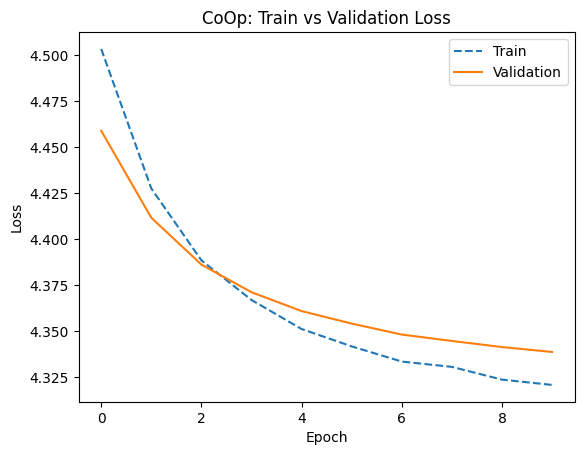

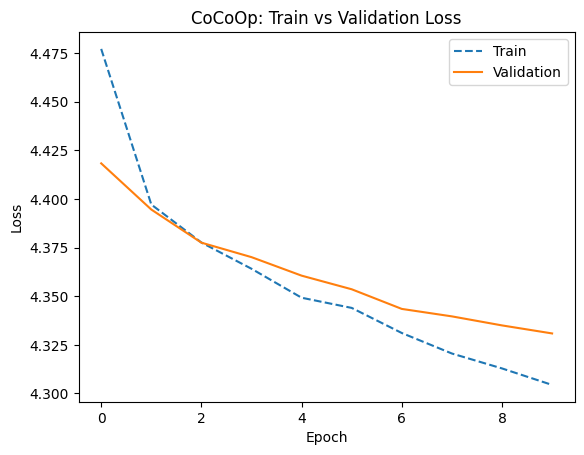

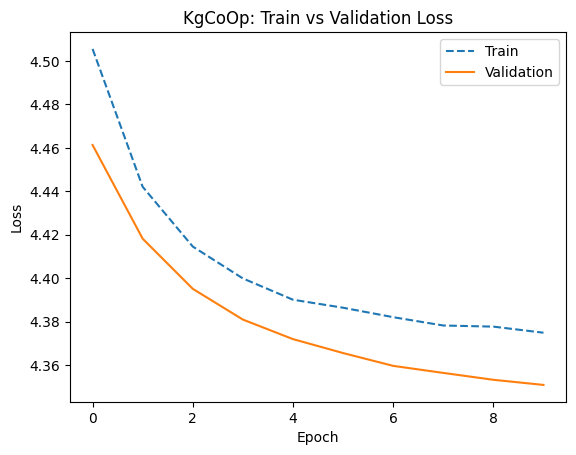

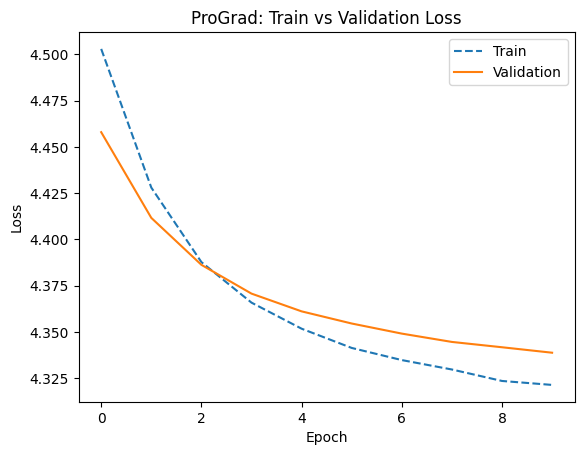

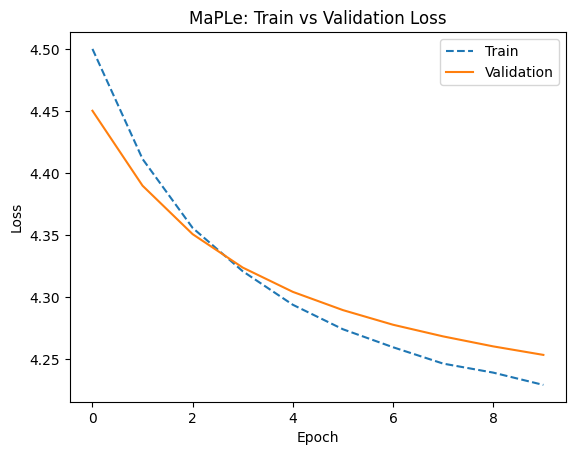

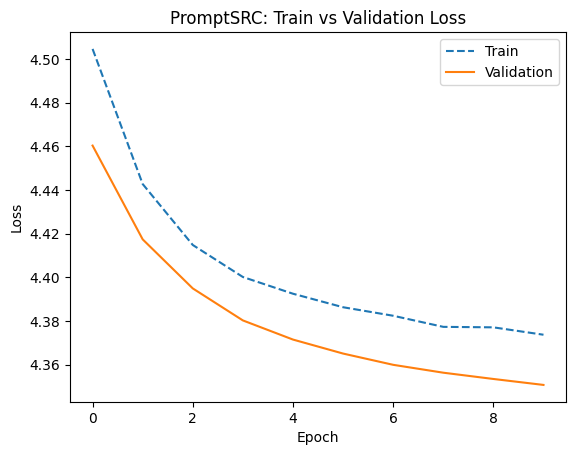

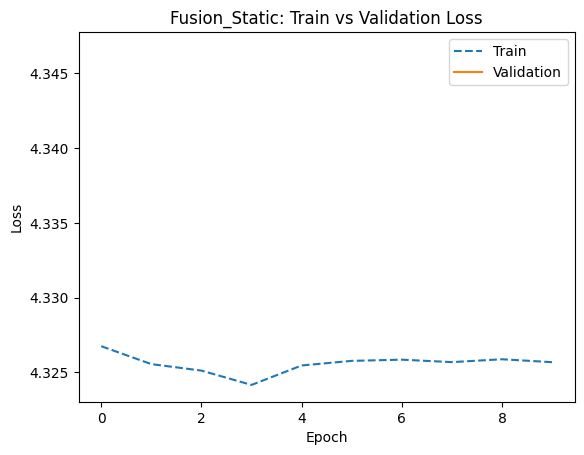

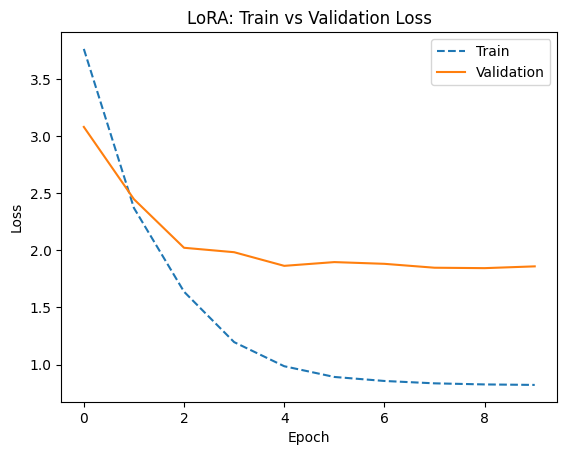

In [105]:
for name, losses in all_losses.items():
    plt.figure()

    plt.plot(losses["train"], linestyle='--', label="Train")
    plt.plot(losses["val"], linestyle='-', label="Validation")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name}: Train vs Validation Loss")
    plt.legend()

    plt.show()

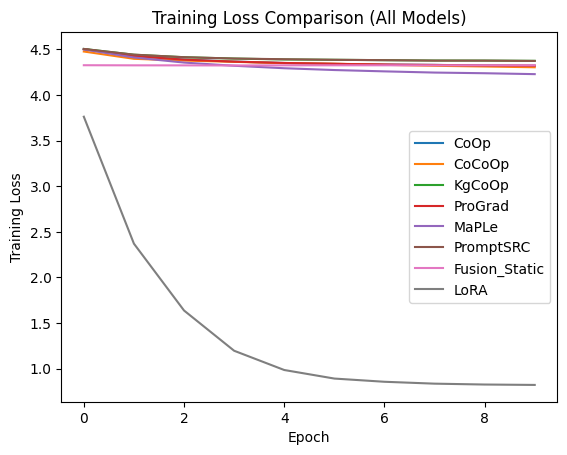

In [106]:
plt.figure()

for name, losses in all_losses.items():
    plt.plot(losses["train"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison (All Models)")
plt.legend()
plt.show()

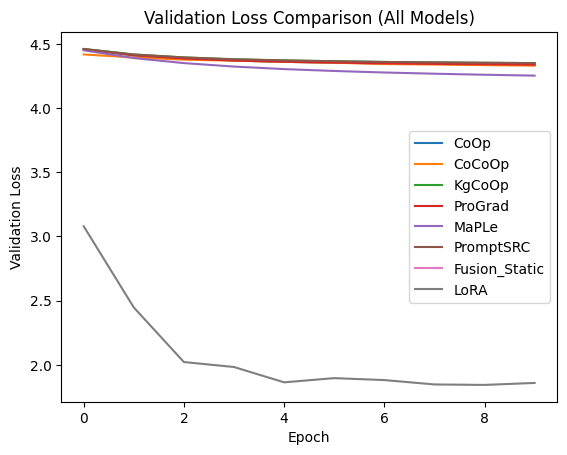

In [107]:
plt.figure()

for name, losses in all_losses.items():
    plt.plot(losses["val"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison (All Models)")
plt.legend()
plt.show()

In [108]:
table_data = []

for name in all_losses.keys():
    train_final = all_losses[name]["train"][-1]
    val_final = all_losses[name]["val"][-1]
    acc = results.get(name, None)

    gap = val_final - train_final

    table_data.append([name, train_final, val_final, acc[0]])

df = pd.DataFrame(
    table_data,
    columns=["Model", "Final Train Loss", "Final Val Loss", "Accuracy"]
)

df = df.sort_values(by="Accuracy", ascending=False)

print(df)

           Model  Final Train Loss  Final Val Loss  Accuracy
7           LoRA          0.821331        1.858997  0.695470
6  Fusion_Static          4.325683        4.346621  0.407141
5      PromptSRC          4.373673        4.350678  0.392739
0           CoOp          4.320755        4.338665  0.376838
2         KgCoOp          4.374926        4.350899  0.373237
3        ProGrad          4.321418        4.338812  0.362436
4          MaPLe          4.229025        4.253279  0.358236
1         CoCoOp          4.304393        4.330852  0.097810


In [109]:
for k, v in results.items():
    print(f"{k}: Top-1={v[0]:.4f}, Top-5={v[1]:.4f}")

Zero-shot: Top-1=0.2304, Top-5=0.5848
Ensemble: Top-1=0.2328, Top-5=0.5878
CuPL: Top-1=0.2412, Top-5=0.6091
CoOp: Top-1=0.3768, Top-5=0.7333
CoCoOp: Top-1=0.0978, Top-5=0.3036
KgCoOp: Top-1=0.3732, Top-5=0.7375
ProGrad: Top-1=0.3624, Top-5=0.7297
MaPLe: Top-1=0.3582, Top-5=0.7174
PromptSRC: Top-1=0.3927, Top-5=0.7345
Fusion_Static: Top-1=0.4071, Top-5=0.7450
Fusion_Dynamic: Top-1=0.3501, Top-5=0.7156
LoRA: Top-1=0.6955, Top-5=0.9196


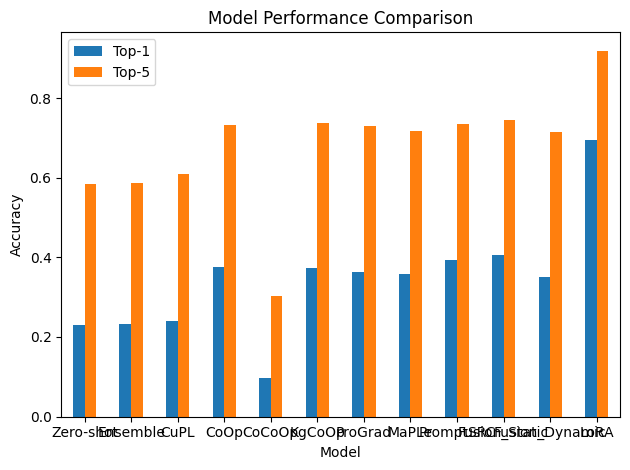

In [110]:
acc_results = {
    k: (v[0], v[1])  # keep only Top-1 and Top-5 accuracies
    for k, v in results.items()
}
accuracies = pd.DataFrame.from_dict(acc_results,orient='index',columns=["Top-1", "Top-5"])

accuracies.plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [111]:
def compare_pca_all(results, models_dict, dataloader, n_components=2):
    all_features = {}

    for name, entry in models_dict.items():

        # Zero-shot
        if entry is None:
            all_features[name] = zs_features.float().cpu().numpy()
            continue

        # Tuple entries — special model types
        if isinstance(entry, tuple):
            tag = entry[0]

            if tag == "cocoop":
                _, m = entry
                m.eval()
                with torch.no_grad():
                    all_features[name] = cocoop_get_text_features(m, dataloader).float().cpu().numpy()

            elif tag == "fusion_static":
                _, m = entry
                m.eval()
                with torch.no_grad():
                    tf_list = m()  # list of (n_cls, 512) tensors from sub-models
                    mean_tf = torch.stack([t.float() for t in tf_list]).mean(dim=0)
                    mean_tf = mean_tf / mean_tf.norm(dim=-1, keepdim=True)
                    all_features[name] = mean_tf.cpu().numpy()

            elif tag == "fusion_dynamic":
                _, maple_m, cocoop_m = entry
                maple_m.eval()
                cocoop_m.eval()
                with torch.no_grad():
                    # MaPLe text features
                    maple_tf = maple_m().float()
                    # CoCoOp: average shift over dataloader
                    cocoop_tf = cocoop_get_text_features(cocoop_m, dataloader).float()
                    mean_tf = (maple_tf + cocoop_tf) / 2
                    mean_tf = mean_tf / mean_tf.norm(dim=-1, keepdim=True)
                    all_features[name] = mean_tf.cpu().numpy()
        else:
            entry.eval()
            with torch.no_grad():
                all_features[name] = entry().float().cpu().numpy()

    names   = list(all_features.keys())
    sizes   = [all_features[n].shape[0] for n in names]
    stacked = np.vstack([all_features[n] for n in names])

    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(stacked)

    var_explained = pca.explained_variance_ratio_
    print(f"PCA variance explained — PC1: {var_explained[0]:.2%}, PC2: {var_explained[1]:.2%}")

    split_features = {}
    idx = 0
    for name, size in zip(names, sizes):
        split_features[name] = reduced[idx: idx + size]
        idx += size

    n_models = len(names)
    cols = 3
    rows = (n_models + cols - 1) // cols
    cmap = plt.cm.get_cmap("tab20", len(classnames))
    class_indices = np.arange(len(classnames))

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for i, name in enumerate(names):
        ax = axes[i]
        coords = split_features[name]
        acc = results.get(name)
        acc_str = f"  Top-1: {acc[0]:.3f}" if acc is not None else ""
        ax.scatter(coords[:, 0], coords[:, 1], c=class_indices,
                   cmap=cmap, s=20, alpha=0.7)
        ax.set_title(f"{name}{acc_str}", fontsize=11)
        ax.set_xlabel(f"PC1 ({var_explained[0]:.1%})")
        ax.set_ylabel(f"PC2 ({var_explained[1]:.1%})")

    for j in range(len(names), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("PCA of Learned Text Feature Space (joint projection)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(9, 7))
    colours = plt.cm.get_cmap("tab10", n_models)

    for i, name in enumerate(names):
        coords = split_features[name]
        acc = results.get(name)
        acc_str = f" ({acc[0]:.3f})" if acc is not None else ""
        ax2.scatter(coords[:, 0], coords[:, 1], label=f"{name}{acc_str}",
                    color=colours(i), s=15, alpha=0.6)

    ax2.set_title("All Models — Text Feature Space (joint PCA)")
    ax2.set_xlabel(f"PC1 ({var_explained[0]:.1%})")
    ax2.set_ylabel(f"PC2 ({var_explained[1]:.1%})")
    ax2.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

    return split_features, pca

PCA variance explained — PC1: 23.94%, PC2: 13.94%


/tmp/ipykernel_4988/614706527.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(classnames))


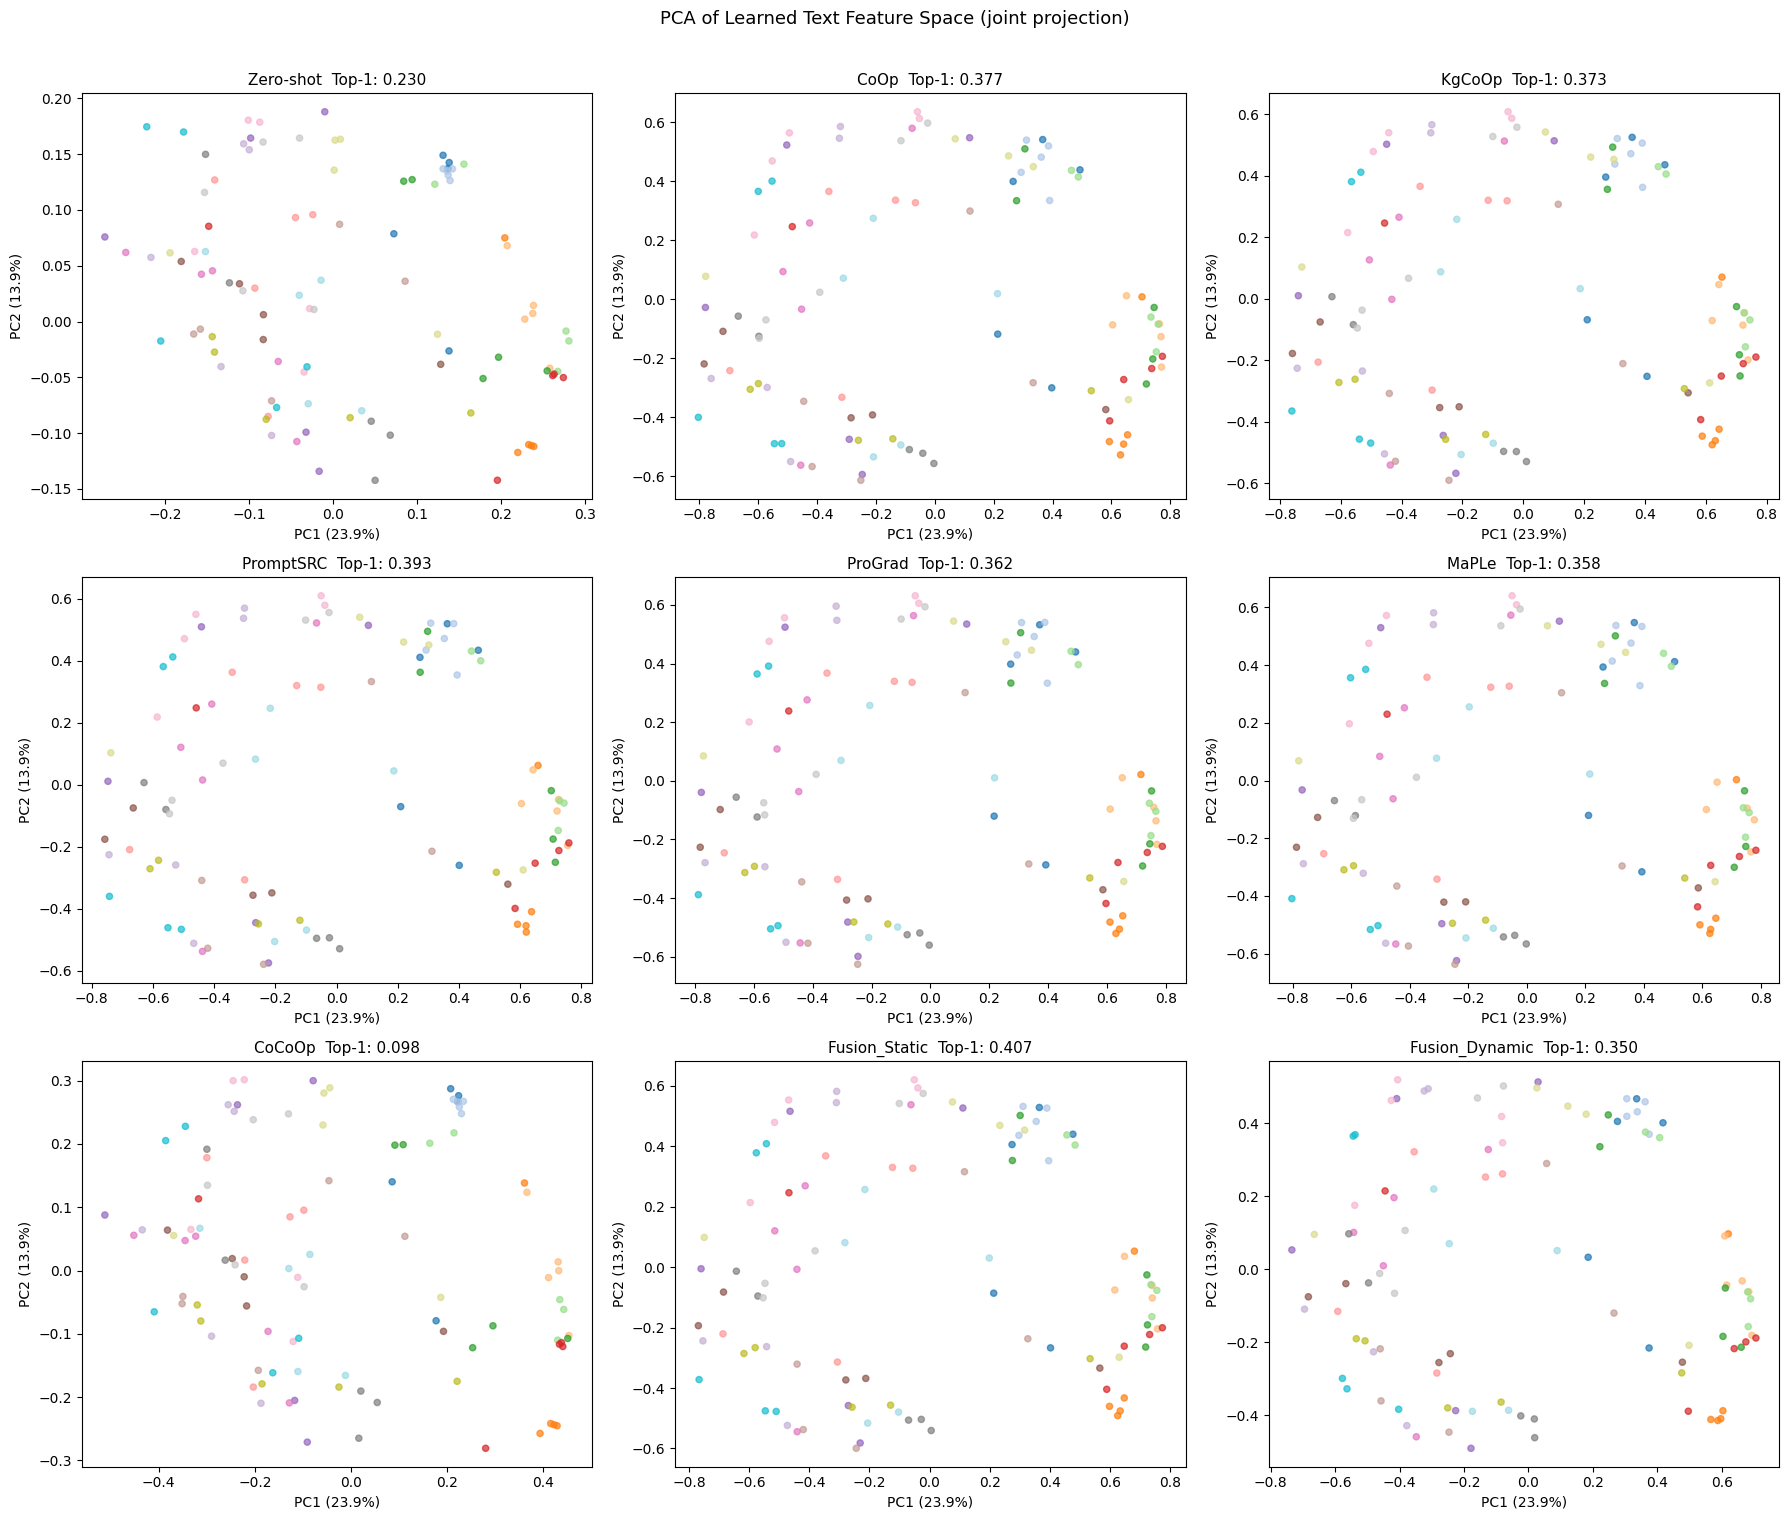

/tmp/ipykernel_4988/614706527.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = plt.cm.get_cmap("tab10", n_models)


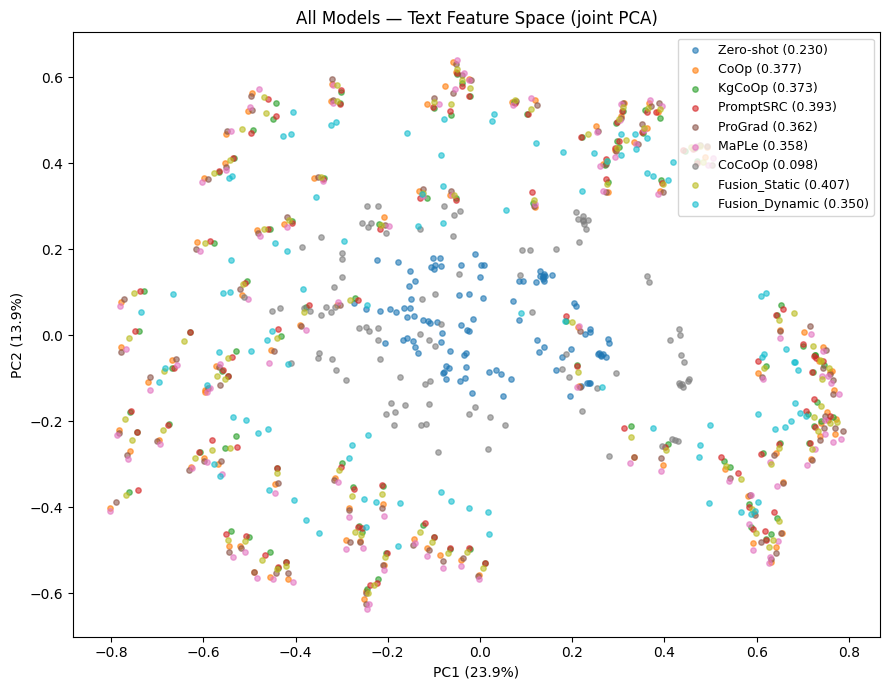

In [112]:
models_dict = {
    "Zero-shot":      None,
    "CoOp":           coop_model,
    "KgCoOp":         kgcoop_model,
    "PromptSRC":      promptsrc_model,
    "ProGrad":        prograd_model,
    "MaPLe":          maple_model,
    "CoCoOp":         ("cocoop",         cocoop_model),
    "Fusion_Static":  ("fusion_static",  fusion_static_model),
    "Fusion_Dynamic": ("fusion_dynamic", maple_model, cocoop_model),
}

split_features, pca = compare_pca_all(results, models_dict, train_loader)

### CSV files

In [104]:
# 1. Top-1 / Top-5 accuracy for every model
accuracy_rows = []
for name, val in results.items():
    if isinstance(val, tuple) and len(val) >= 2:
        accuracy_rows.append({
            "Model":  name,
            "Top-1":  round(float(val[0]), 4),
            "Top-5":  round(float(val[1]), 4),
        })

df_accuracy = pd.DataFrame(accuracy_rows).sort_values("Top-1", ascending=False)
df_accuracy.to_csv("results_accuracy.csv", index=False)
print(df_accuracy.to_string(index=False))

# ── 2. Per-epoch train / val loss for every model ───────────────────────────
loss_rows = []
for name, losses in all_losses.items():
    for epoch, (t, v) in enumerate(zip(losses["train"], losses["val"]), start=1):
        loss_rows.append({
            "Model":       name,
            "Epoch":       epoch,
            "Train Loss":  round(t, 4),
            "Val Loss":    round(v, 4),
        })

df_losses = pd.DataFrame(loss_rows)
#df_losses.to_csv("results_losses.csv", index=False)
#print(f"\nLoss curves saved — {len(df_losses)} rows")

drive_path = "/content/drive/MyDrive/Colab Notebooks/EEEM068 - Applied Machine Learning/COURSEWORK/"

os.makedirs(drive_path, exist_ok=True)  # creates folder if it doesn't exist

df_accuracy.to_csv(os.path.join(drive_path, "results_accuracy.csv"), index=False)
df_losses.to_csv(os.path.join(drive_path, "results_losses.csv"), index=False)

print("Saved to Google Drive.")

         Model  Top-1  Top-5
          LoRA 0.6955 0.9196
 Fusion_Static 0.4071 0.7450
     PromptSRC 0.3927 0.7345
          CoOp 0.3768 0.7333
        KgCoOp 0.3732 0.7375
       ProGrad 0.3624 0.7297
         MaPLe 0.3582 0.7174
Fusion_Dynamic 0.3501 0.7156
          CuPL 0.2412 0.6091
      Ensemble 0.2328 0.5878
     Zero-shot 0.2304 0.5848
        CoCoOp 0.0978 0.3036
Saved to Google Drive.
